## Perceptron

In [481]:
import numpy as np


In [482]:
# Função Sinal

def sign(z):
    return np.where(z >0, 1, 0)

In [483]:
# Perceptron

def perceptron(x,w,b):
  z = np.dot(x,w)+b
  return sign(z)

In [484]:
# Treinamento do Perceptron (atualização exemplo por exemplo)

def treinar_perceptron(X, d, eta=0.1, epocas=1000):
    n_amostras, n_atributos = X.shape
    w = np.random.uniform(-1,1,n_atributos)
    b = np.random.uniform(-1,1)

    for epoca in range(epocas):
        erros_na_epoca = 0
        for i in range(n_amostras):
            x_i = X[i]
            y_esperado = d[i]

            z = np.dot(x_i, w) + b
            y_pred = sign(z)

            erro = y_esperado - y_pred
            if erro != 0:
                w += eta * erro * x_i
                b += eta * erro
                erros_na_epoca += 1

        # Se não houve nenhum erro nesta época, o perceptron convergiu!
        if erros_na_epoca == 0:
            print(f"Convergiu na época {epoca + 1}!")
            break

    return w, b

In [485]:


# Gerando os dados

n_alunos=50
mean=7
std=2

X=np.random.normal(loc=mean,scale=std,size=(n_alunos,2))
X=np.clip(X,0,10)
print(X)





[[10.          9.01963418]
 [ 5.62369931 10.        ]
 [ 8.96353097  6.35033723]
 [ 2.00118857 10.        ]
 [ 4.22085507  3.70920251]
 [ 9.04514086 10.        ]
 [ 9.76854564  8.12781824]
 [ 8.18950868  8.70683112]
 [ 8.51785718  7.56238285]
 [ 7.20840221  6.87481374]
 [ 5.49207082  6.43864985]
 [ 3.61408637  6.80332075]
 [ 5.02281779  4.79282137]
 [ 7.3597883   9.78400457]
 [ 8.83663321  3.85899879]
 [ 5.02074373  8.88154238]
 [ 5.03502521  6.5507337 ]
 [ 8.1001042   5.06331109]
 [ 7.21075101  4.33194901]
 [ 5.79726471  7.63956387]
 [ 3.81401253  7.88094948]
 [ 6.9607244   8.10497991]
 [ 7.44782827  9.72828086]
 [ 7.25044901  6.14118892]
 [ 7.24459501  8.08659606]
 [ 7.09772014  7.08118338]
 [ 5.59601662  5.67419816]
 [ 4.19478946 10.        ]
 [ 4.51227353  5.6141896 ]
 [ 5.56318547  8.78984875]
 [ 6.41010064  9.49548415]
 [ 5.65301875  7.55798832]
 [ 5.32930589 10.        ]
 [ 4.62480316  7.61964142]
 [ 8.26755376  7.82759819]
 [ 6.62942468  6.7403586 ]
 [ 7.08762294  6.705996  ]
 

In [486]:
# definindo os rótulos

d=(np.average(X,axis=1)>=mean)+0.0

print(d)



[1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0.
 1. 1. 0. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0.
 1. 0.]


Convergiu na época 53!


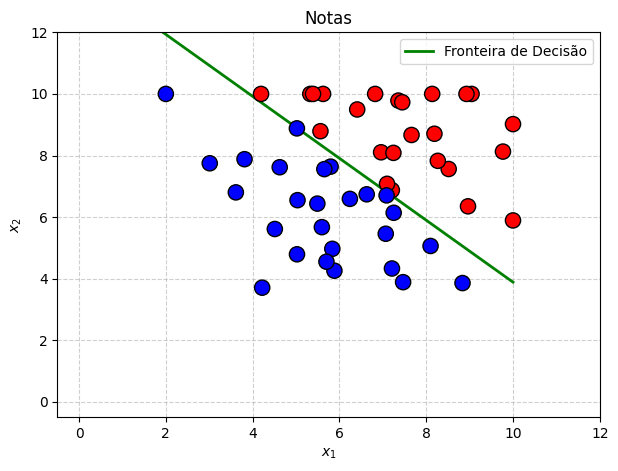

In [487]:

import matplotlib.pyplot as plt

w,b=treinar_perceptron(X,d)


# Cálculo da linha da fronteira de decisão: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b) / w2
x1_vals = np.linspace(-0.5, 10.0, 100)

# Evita divisão por zero caso w[1] seja 0
if w[1] != 0:
    x2_vals = -(w[0] * x1_vals + b) / w[1]
else:
    x2_vals = np.zeros_like(x1_vals)

# Plot
plt.figure(figsize=(7, 5))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=d,
    cmap="bwr",
    edgecolors="k",
    s=120,
    zorder=3,

)
plt.plot(
    x1_vals,
    x2_vals,
    "g-",
    linewidth=2,
    label="Fronteira de Decisão",
    zorder=2,
)

plt.xlim(-0.5, 12.0)
plt.ylim(-0.5, 12.0)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.legend(loc="upper right")
plt.title("Notas")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()